In [1]:
import numpy as np
import torch
import scipy.io
import yaml
from enum import Enum, auto

import sys
sys.path.insert(0, '../')
sys.path.insert(0, '../dataset')
sys.path.insert(0, '../vae')

import network
import data_preprocess
import train_vae
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib import rc
from ipywidgets import interact, RadioButtons
import os


import dataset.supershape as ss
import dataset.mesher as mesher
# Set the global font to be DejaVu Sans, size 10 (or any other sans-serif font of your choice!)
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans'],'size':10})

# Set the font used for MathJax - more on this later
rc('mathtext',**{'default':'regular'})

# Read Configuration File

In [2]:
with open("vae_config.yaml", "r") as file:
  vae_config = yaml.safe_load(file)

with open("datagen.yaml", "r") as file:
  data_config = yaml.safe_load(file)

# Load SuperShape Data

In [3]:
dataset_num  = data_config['DATASET']['dataset_num']
mstr_shape_params = scipy.io.loadmat(f'../dataset/mstr_shape_parameters_{dataset_num}.mat'
                                     )['mstr_shape_parameters']
mstr_homog_data = scipy.io.loadmat(f'../dataset/homogen_data_{dataset_num}.mat')
mstr_area = scipy.io.loadmat(f'../dataset/mstr_area_{dataset_num}.mat')['mstr_area']
mstr_perim = scipy.io.loadmat(f'../dataset/mstr_perim_{dataset_num}.mat')['mstr_perim']
c00, c10, c01, c11 = (mstr_homog_data['c00'], mstr_homog_data['c10'],
                       mstr_homog_data['c01'], mstr_homog_data['c11'])

# Plot Data Distribution

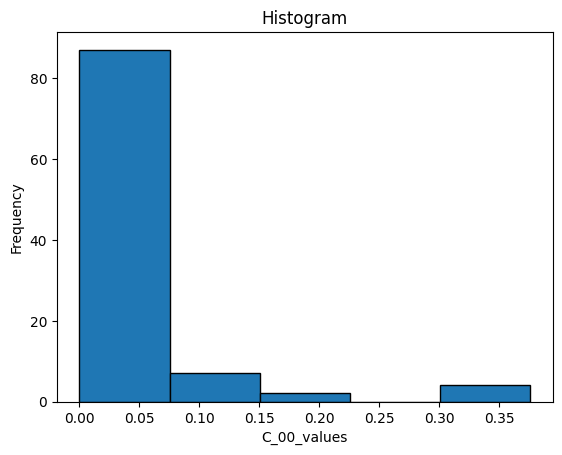

In [4]:
plt.hist(c00, bins=5, edgecolor='black')

# Customize plot
plt.title('Histogram')
plt.xlabel('C_00_values')
plt.ylabel('Frequency')

# Display the plot
plt.show()

# Normalize data

In [5]:
mstr_data = torch.tensor(np.hstack((mstr_shape_params, c00, c11,
                                    mstr_perim.reshape((-1, 1)),
                                    mstr_area.reshape((-1, 1))
                                    ))).double()
# 8 LINEAR = a, b, m, n1, n2, n3, cx, cy
# 2 LOG =  c00, c11
# 2 LINEAR =  perim, area
normalization_types = [data_preprocess.NomalizationType.LINEAR] * 8 + [data_preprocess.NomalizationType.LOG] * 2 + [data_preprocess.NomalizationType.LINEAR] * 2
normalized_train_data, max_feature, min_feature = data_preprocess.stack_train_data(mstr_data, normalization_types)
torch.save({'max_feature': max_feature, 'min_feature': min_feature}, '../vae/nomalization.pt')


In [6]:
num_samples, num_features = normalized_train_data.shape

# Train VAE

In [7]:
vae_yaml = vae_config['NETWORK']
vae_params = network.VAE_Params(input_dim=num_features,
                                encoder_hidden_dim=vae_yaml['encoder_hidden_dim'],
                                latent_dim=vae_yaml['latent_dim'],
                                decoder_hidden_dim=vae_yaml['decoder_hidden_dim'])
print(vae_yaml['latent_dim'])

2


In [8]:
vae_net = network.VariationalAutoencoder(vae_params=vae_params)

In [9]:
folder_path = "../vae"
file_name = "vae_net.pt"
file_path = os.path.join(folder_path, file_name)
if not os.path.isfile(file_path):
  opt_yaml = vae_config['OPTIMIZATION']
  convg_history = train_vae.train_autoencoder(vae=vae_net,
                                              train_data=normalized_train_data,
                                              num_epochs=opt_yaml['num_epochs'],
                                              kl_factor=opt_yaml['kl_factor'],
                                              lr = opt_yaml['lr'],
                                              save_file = file_path)

iter 0 	 recon_loss 	 8.14E-02 	 kl_loss 9.36E+01 	 net_loss 8.14E-02


iter 500 	 recon_loss 	 7.24E-04 	 kl_loss 2.37E+03 	 net_loss 9.61E-04


iter 1000 	 recon_loss 	 2.33E-04 	 kl_loss 2.05E+03 	 net_loss 4.38E-04


iter 1500 	 recon_loss 	 1.25E-04 	 kl_loss 1.78E+03 	 net_loss 3.03E-04


iter 2000 	 recon_loss 	 7.99E-05 	 kl_loss 1.64E+03 	 net_loss 2.43E-04


...

iter 14500 	 recon_loss 	 6.02E-05 	 kl_loss 1.24E+03 	 net_loss 1.84E-04


iter 15000 	 recon_loss 	 3.69E-05 	 kl_loss 1.22E+03 	 net_loss 1.59E-04


iter 15500 	 recon_loss 	 7.07E-05 	 kl_loss 1.21E+03 	 net_loss 1.92E-04


iter 16000 	 recon_loss 	 4.52E-05 	 kl_loss 1.16E+03 	 net_loss 1.61E-04


iter 16500 	 recon_loss 	 1.37E-04 	 kl_loss 1.28E+03 	 net_loss 2.64E-04


# Load VAE

In [10]:
if os.path.isfile(file_path):
    vae_net.encoder.is_training = False
    vae_net.load_state_dict(torch.load(file_path))
    vae_net.eval()
    print("Loading VAE")

Loading VAE


In [11]:
vae_output = vae_net(normalized_train_data)

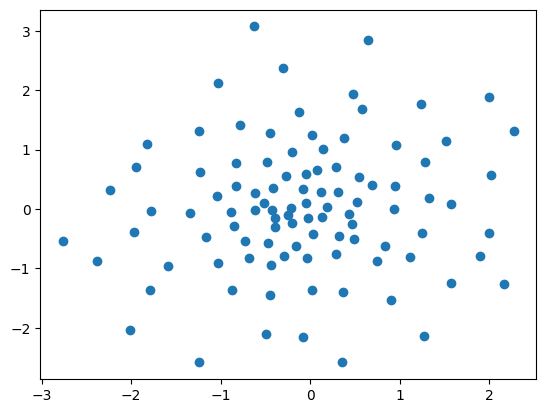

In [12]:
vae_latent_encoding = vae_net.encoder(normalized_train_data).detach().numpy()
plt.scatter(vae_latent_encoding[:,0], vae_latent_encoding[:,1])

# Inetractive Latent Space Plot

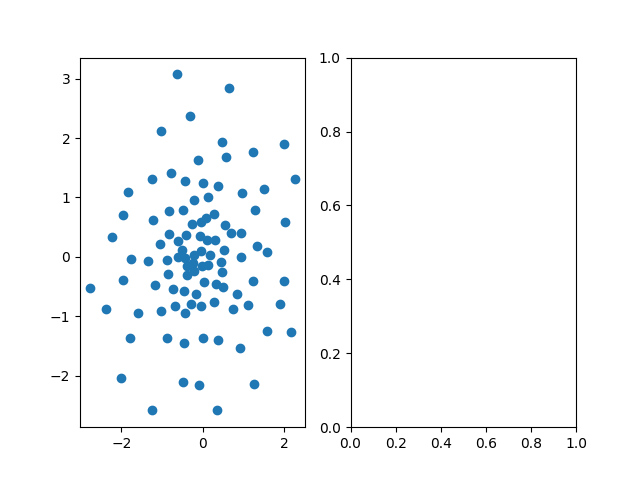

In [13]:
%matplotlib widget

def interactive_z_space_plot():

  def on_pick(event):
    pt = [event.xdata, event.ydata]
    if pt[0] is not None and pt[1] is not None:
      latent_point = torch.tensor(pt).view((-1, 2)).double()
      decoded = vae_net.decoder(latent_point)
      renormalized_output = data_preprocess.stack_vae_output(decoded, max_feature, min_feature, normalization_types).reshape(-1)
      shape_params_array = renormalized_output.detach().numpy()
      recon_shape = ss.SuperShapes.from_array(shape_params_array,
                                            num_shapes=1)

      x, y = ss.get_euclidean_coords_of_points_on_surf_super_shape(recon_shape)
      ax[1].clear()
      ax[1].patch.set_facecolor('#DAE8FC') # blue
      ax[1].fill(x[0, :], y[0, :], facecolor='#F8CECC', edgecolor='black')
      ax[1].set_xlim([recon_shape.bounding_box.x_min, recon_shape.bounding_box.x_max])
      ax[1].set_ylim([recon_shape.bounding_box.y_min, recon_shape.bounding_box.y_max])
    return event.xdata, event.ydata
  fig, ax = plt.subplots(1, 2)
  ax[0].scatter(vae_latent_encoding[:,0], vae_latent_encoding[:,1])
  cid = fig.canvas.mpl_connect('button_press_event', on_pick)

interactive_z_space_plot()
# fig.canvas.mpl_disconnect(cid)